# EDA Ecobici

### Verificar cómo se está guardando el cicloestacionretiro
Sale como valor no numérico en el ingest.py

In [62]:
import sys
sys.path.append("../src")
import pandas as pd
import glob

paths = sorted(glob.glob("../data/raw/*.csv"))
print(paths)

frames = [pd.read_csv(p, low_memory=False) for p in paths]
raw = pd.concat(frames, ignore_index=True)
raw.columns = [c.strip().lower().replace("_", "").replace(" ", "") for c in raw.columns]

for col in ["cicloestacionretiro", "cicloestacionarribo"]:
    vals = raw[col].astype(str)
    no_numericos = vals[~vals.str.match(r"^\d+$")]
    print(f"\n--- {col}: {len(no_numericos)} valores no numéricos ---")
    print(no_numericos.value_counts().head(20))

['../data/raw/2026-03.csv', '../data/raw/2026-04.csv', '../data/raw/2026-05.csv', '../data/raw/2026-06.csv', '../data/raw/2026-07.csv', '../data/raw/2026-08.csv']

--- cicloestacionretiro: 331089 valores no numéricos ---
cicloestacionretiro
271-272       65140
237-238       42685
158-159       36574
107-108       29175
390-391       29027
192-193       28561
273-274       28052
266-267       27008
235-236       16635
268-269       13853
445-446        8297
264-275        5360
Temporal 1      570
Temporal 2      130
Temporal 3       16
Temporal 4        6
Name: count, dtype: int64

--- cicloestacionarribo: 380029 valores no numéricos ---
cicloestacionarribo
271-272       105805
266-267        42711
273-274        37732
158-159        36183
237-238        33101
107-108        27705
192-193        24300
390-391        23935
235-236        16068
268-269        13871
264-275         9431
445-446         8366
Temporal 1       606
Temporal 2       159
Temporal 3        31
Temporal 4        25

In [63]:
trips = pd.read_parquet("../data/processed/trips_clean.parquet")

sospechosas = trips[trips["origen_dt"] < "2025-01-01"]
print(f"Filas con fecha de origen antes de 2025: {len(sospechosas)}")
print(sospechosas[["archivo_origen", "fecha_origen", "hora_origen", "estacion_origen", "duracion_min"]].head(20))

Filas con fecha de origen antes de 2025: 3
        archivo_origen fecha_origen hora_origen estacion_origen  duracion_min
433265     2026-03.csv   04/08/2024    13:34:41              25     837927.95
2450217    2026-04.csv   14/11/2023    12:34:18             110    1273464.70
6845865    2026-07.csv   03/10/2022    19:17:58             260    1981882.65


### Verificar que los registros de estaciones siguen un patrón

In [64]:
stations = pd.read_csv("../data/processed/stations.csv", dtype={"station_id": "string"})
ids_validos = set(stations["station_id"])

pares = ["271-272", "237-238", "158-159", "192-193", "107-108",
         "266-267", "273-274", "390-391", "235-236", "268-269", "445-446"]

for par in pares:
    a, b = par.split("-")
    print(f"{par}: ¿{a} existe? {a in ids_validos} | ¿{b} existe? {b in ids_validos}")

271-272: ¿271 existe? True | ¿272 existe? True
237-238: ¿237 existe? True | ¿238 existe? True
158-159: ¿158 existe? True | ¿159 existe? True
192-193: ¿192 existe? True | ¿193 existe? True
107-108: ¿107 existe? True | ¿108 existe? True
266-267: ¿266 existe? True | ¿267 existe? True
273-274: ¿273 existe? True | ¿274 existe? False
390-391: ¿390 existe? True | ¿391 existe? True
235-236: ¿235 existe? True | ¿236 existe? True
268-269: ¿268 existe? True | ¿269 existe? True
445-446: ¿445 existe? True | ¿446 existe? True


### Verificar la cantidad de viajes largos o cortos

In [65]:
trips = pd.read_parquet("../data/processed/trips_clean.parquet")

muy_cortos = (trips["duracion_min"] < 1).sum()
muy_largos = (trips["duracion_min"] > 45).sum()
total = len(trips)

print(f"Viajes < 1 min: {muy_cortos:,} ({muy_cortos/total:.2%})")
print(f"Viajes > 45 min (límite oficial): {muy_largos:,} ({muy_largos/total:.2%})")

Viajes < 1 min: 1,129 (0.01%)
Viajes > 45 min (límite oficial): 163,614 (1.75%)


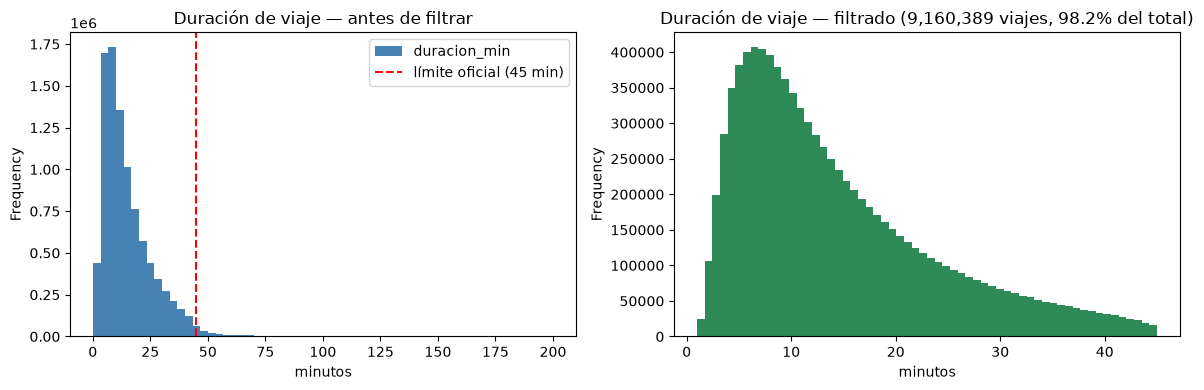

In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes: distribución completa (se ve dominada por los outliers extremos)
trips["duracion_min"].clip(upper=200).plot.hist(bins=60, ax=axes[0], color="steelblue")
axes[0].axvline(45, color="red", linestyle="--", label="límite oficial (45 min)")
axes[0].set_title("Duración de viaje — antes de filtrar")
axes[0].set_xlabel("minutos")
axes[0].legend()

# Después: solo viajes dentro del rango válido (1-45 min)
validos = trips[(trips["duracion_min"] >= 1) & (trips["duracion_min"] <= 45)]
validos["duracion_min"].plot.hist(bins=60, ax=axes[1], color="seagreen")
axes[1].set_title(f"Duración de viaje — filtrado ({len(validos):,} viajes, {len(validos)/len(trips):.1%} del total)")
axes[1].set_xlabel("minutos")

plt.tight_layout()
plt.savefig("../figures/duracion_antes_despues.png", dpi=150)
plt.show()

## 1. Nulos

In [67]:
trips.isna().mean().sort_values(ascending=False)

estacion_destino         4.075320e-02
estacion_origen          3.550502e-02
edad                     2.831059e-05
genero                   1.072371e-07
bici_id                  0.000000e+00
fecha_origen             0.000000e+00
hora_origen              0.000000e+00
fecha_destino            0.000000e+00
hora_destino             0.000000e+00
origen_dt                0.000000e+00
destino_dt               0.000000e+00
archivo_origen           0.000000e+00
duracion_min             0.000000e+00
hora_del_dia             0.000000e+00
dia_semana               0.000000e+00
fecha                    0.000000e+00
es_fin_de_semana         0.000000e+00
estacion_origen_tipo     0.000000e+00
estacion_destino_tipo    0.000000e+00
dtype: float64

## 2. Outliers de duración

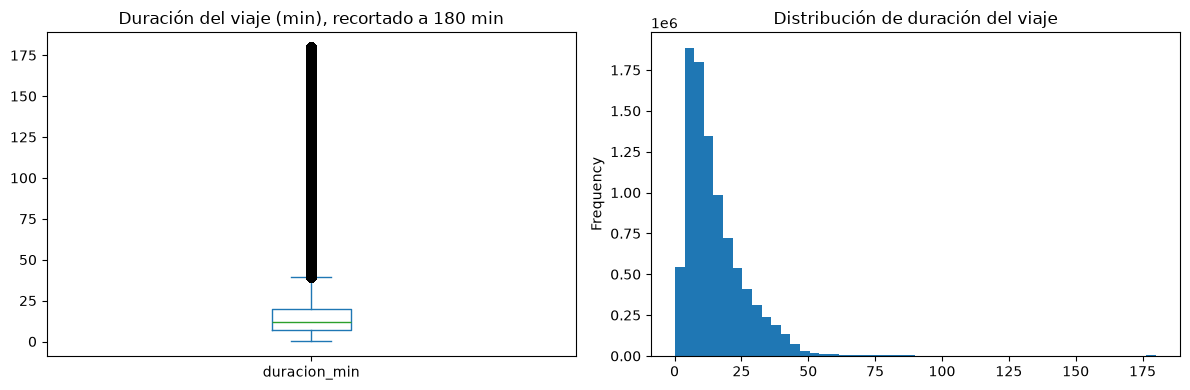

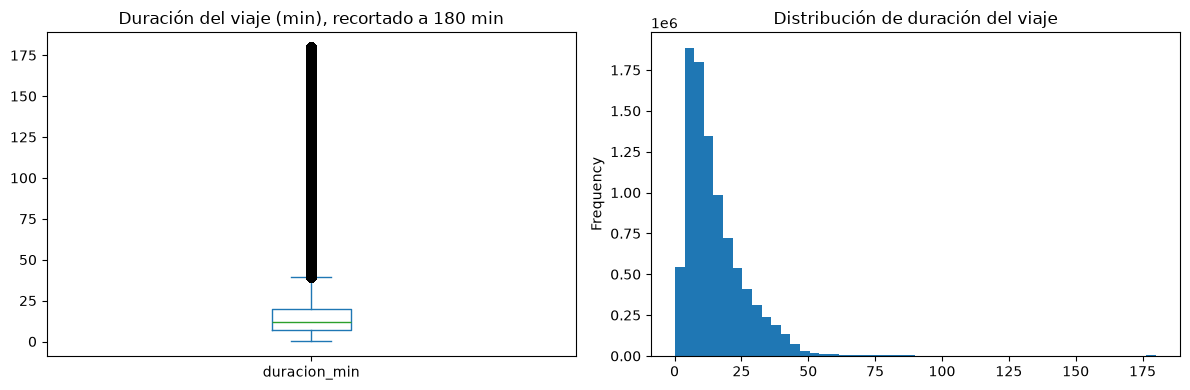

In [68]:
plot_outliers_duracion(trips)

## 3. Viajes por hora del día

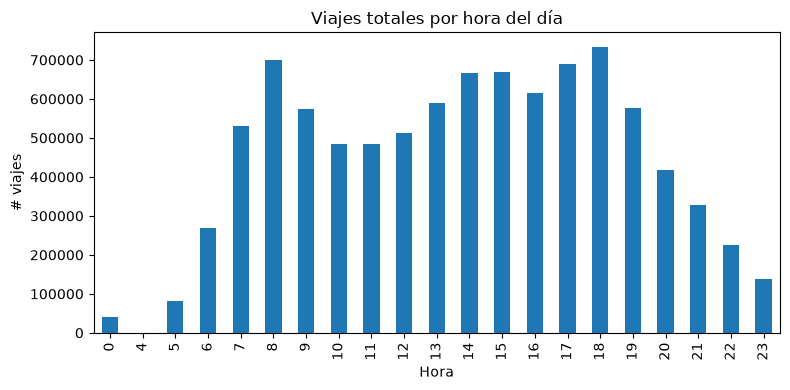

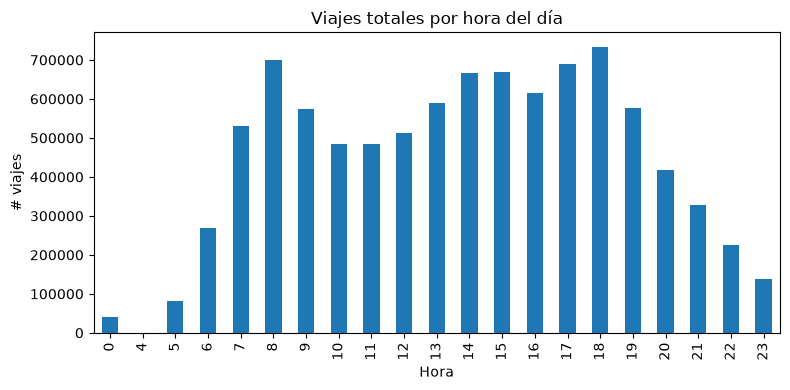

In [69]:
plot_viajes_por_hora(trips)

## 4. Top estaciones por demanda

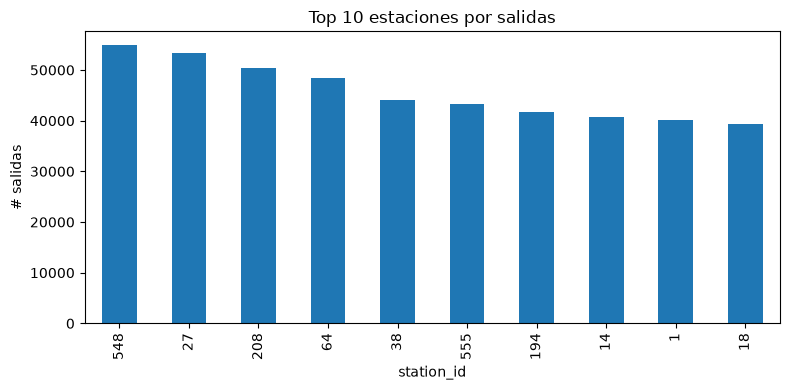

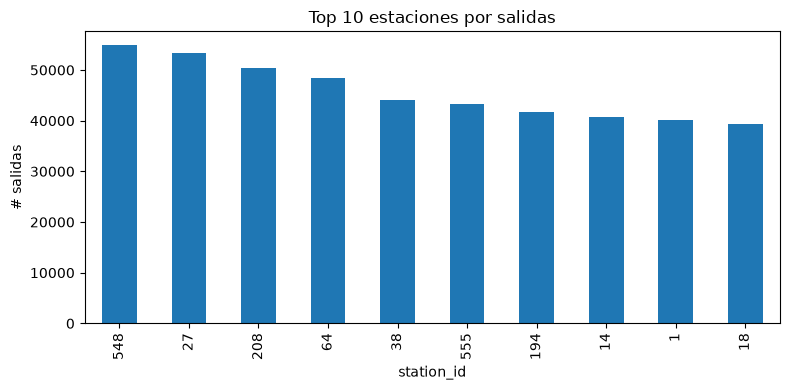

In [70]:
plot_top_estaciones(trips)

## 5. Demanda agregada estacion-fecha-hora (input para el modelo)

In [71]:
demanda = demanda_por_estacion_hora(trips)
demanda.head()

,estacion_origen,fecha,hora_del_dia,salidas
0,1,2026-03-01,7,1
1,1,2026-03-01,8,7
2,1,2026-03-01,9,5
3,1,2026-03-01,10,12
4,1,2026-03-01,11,17


# 6. Top estaciones con actividad

In [72]:
nombres = stations.set_index("station_id")["nombre"]
top10 = validos["estacion_origen"].value_counts().head(10)
top10.index = top10.index.map(nombres)
print(top10)

estacion_origen
CE-652 Xicoténcatl - División del Norte               54314
CE-365 Holbein-Avenida Revolución                     51694
CE-457 Av. Prado Norte-Explanada                      49839
CE-284 Dakota-Vermont                                 47877
CE-384 Empresa-Poussin                                43439
CE-571 Manuel M. Flores - Calzada San Antonio Abad    42898
CE-710 Molino del Rey - Glorieta de la Lealtad        39645
CE-127 Puebla-Merida                                  39558
CE-022 Reforma - Manchester                           39112
CE-394 Dr. Roberto Gayol-Félix Cuevas                 38197
Name: count, dtype: int64[pyarrow]


# 7. Fin de semana vs entre semana

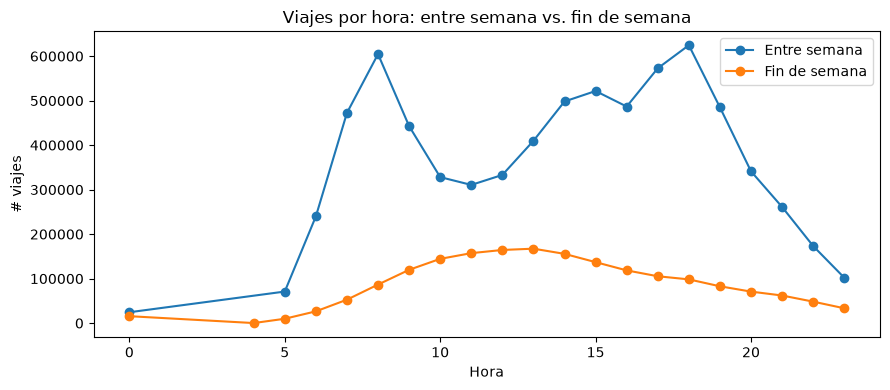

In [73]:
fig, ax = plt.subplots(figsize=(9, 4))
validos[~validos["es_fin_de_semana"]].groupby("hora_del_dia").size().plot(ax=ax, label="Entre semana", marker="o")
validos[validos["es_fin_de_semana"]].groupby("hora_del_dia").size().plot(ax=ax, label="Fin de semana", marker="o")
ax.set_title("Viajes por hora: entre semana vs. fin de semana")
ax.set_xlabel("Hora")
ax.set_ylabel("# viajes")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/entre_semana_vs_finde.png", dpi=150)
plt.show()

# 8. Flujo neto por estación 

In [74]:
salidas = validos.groupby("estacion_origen").size().rename("salidas")
llegadas = validos.groupby("estacion_destino").size().rename("llegadas")

flujo = pd.concat([salidas, llegadas], axis=1).fillna(0)
flujo["neto"] = flujo["llegadas"] - flujo["salidas"]  # negativo = se vacía, positivo = se llena
flujo = flujo.merge(stations.set_index("station_id")[["nombre"]], left_index=True, right_index=True, how="left")

print("Top 10 estaciones que MÁS SE VACÍAN (necesitan restock frecuente):")
print(flujo.sort_values("neto").head(10)[["nombre", "salidas", "llegadas", "neto"]])

print("\nTop 10 estaciones que MÁS SE LLENAN (necesitan que les quiten bicis):")
print(flujo.sort_values("neto", ascending=False).head(10)[["nombre", "salidas", "llegadas", "neto"]])

Top 10 estaciones que MÁS SE VACÍAN (necesitan restock frecuente):
                                            nombre  salidas  llegadas  neto
208               CE-457 Av. Prado Norte-Explanada    49839     42901 -6938
211            CE-278 Mier Y Pesado-Obrero Mundial    21572     15549 -6023
711                                            NaN    16109     10116 -5993
495  CE-703 Miguel Hidalgo - Calzada General Anaya    30115     24379 -5736
494        CE-540 Eucalipto - Ricardo Flores Magón    35679     30283 -5396
710                                            NaN    19618     14524 -5094
465                   CE-004 Río Nilo - Río Panuco    24850     20098 -4752
210         CE-294 Nicolás San Juan-Eje 4 Sur Xola    13557      8809 -4748
675                                            NaN    20017     15390 -4627
204                           CE-213 Solón-Cicerón    13947     10127 -3820

Top 10 estaciones que MÁS SE LLENAN (necesitan que les quiten bicis):
                          

# 9. Flujo neto por estación hora y día

In [75]:
salidas_hora = (
    validos.groupby(["estacion_origen", "hora_del_dia"]).size()
    .rename("salidas")
    .rename_axis(["station_id", "hora_del_dia"])
)
llegadas_hora = (
    validos.groupby(["estacion_destino", "hora_del_dia"]).size()
    .rename("llegadas")
    .rename_axis(["station_id", "hora_del_dia"])
)

flujo_hora = pd.concat([salidas_hora, llegadas_hora], axis=1).fillna(0)
flujo_hora["neto"] = flujo_hora["llegadas"] - flujo_hora["salidas"]
flujo_hora = flujo_hora.reset_index()

peor_hora_por_estacion = flujo_hora.loc[flujo_hora.groupby("station_id")["neto"].idxmin()]
peor_hora_por_estacion = peor_hora_por_estacion.merge(
    stations.set_index("station_id")[["nombre"]], left_on="station_id", right_index=True, how="left"
)
print("Estaciones con el peor momento de vaciado (hora con más salidas netas):")
print(peor_hora_por_estacion.sort_values("neto").head(10)[["nombre", "hora_del_dia", "neto"]])

Estaciones con el peor momento de vaciado (hora con más salidas netas):
                                               nombre  hora_del_dia    neto
1627                       CE-033 Londres - Florencia             7 -3734.0
2313                 CE-457 Av. Prado Norte-Explanada             8 -2600.0
9125          CE-652 Xicoténcatl - División del Norte             7 -2245.0
1942                 CE-337 San Borja-Martín Mendalde            18 -1990.0
7936    CE-703 Miguel Hidalgo - Calzada General Anaya             7 -1937.0
9105     CE-579 Doctor Márquez - Privada Doctor Duran             7 -1931.0
7270                     CE-004 Río Nilo - Río Panuco             8 -1855.0
7480             CE-481 Lago Garda - Mariano Escobedo            17 -1834.0
2412  CE-282 La Morena-Eje 2 Poniente Gabriel Mancera             7 -1798.0
2391              CE-278 Mier Y Pesado-Obrero Mundial             6 -1790.0


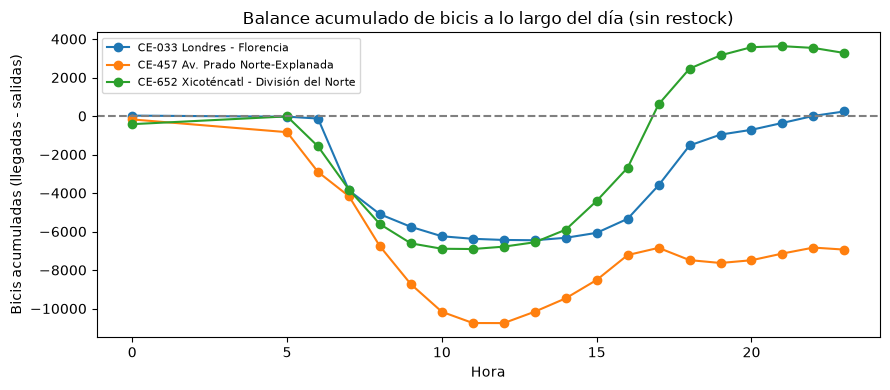

In [76]:
top_problematicas = peor_hora_por_estacion.sort_values("neto").head(3)["station_id"]

fig, ax = plt.subplots(figsize=(9, 4))
for est in top_problematicas:
    serie = flujo_hora[flujo_hora["station_id"] == est].sort_values("hora_del_dia")
    nombre = stations.set_index("station_id").loc[est, "nombre"]
    ax.plot(serie["hora_del_dia"], serie["neto"].cumsum(), marker="o", label=nombre)

ax.axhline(0, color="gray", linestyle="--")
ax.set_title("Balance acumulado de bicis a lo largo del día (sin restock)")
ax.set_xlabel("Hora")
ax.set_ylabel("Bicis acumuladas (llegadas - salidas)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/curva_acumulacion.png", dpi=150)
plt.show()

In [77]:
ids_en_trips = set(validos["estacion_origen"].dropna()) | set(validos["estacion_destino"].dropna())
ids_en_catalogo = set(stations["station_id"])
solo_en_historico = ids_en_trips - ids_en_catalogo
print(f"IDs de estación en el histórico que ya no existen en el catálogo actual: {len(solo_en_historico)}")

IDs de estación en el histórico que ya no existen en el catálogo actual: 34
